<a href="https://colab.research.google.com/github/sayem088/AI-and-Iot-driven-WtE-research-paper-stat/blob/main/Stoten_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_excel("Urban_Waste_Data.xlsx")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359 entries, 0 to 358
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Name                       359 non-null    object 
 1   Gender                     359 non-null    int64  
 2   Age                        359 non-null    int64  
 3   Education                  359 non-null    int64  
 4   Occupation                 339 non-null    float64
 5   HH_Income                  359 non-null    int64  
 6   HH_Size                    359 non-null    int64  
 7   Expenditure                359 non-null    int64  
 8   Duration_Living            359 non-null    int64  
 9   House_Type                 351 non-null    float64
 10  Distance_to_Waste_Point    358 non-null    float64
 11  Waste_Gen_Types            359 non-null    int64  
 12  Waste_Production           358 non-null    float64
 13  WtE_Tech_Awarness          359 non-null    int64  

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing

,0
Subsidy_Amount,0.289694
Amount_Willingness_to_pay,0.270195
WtE_Technology_Preference,0.066852
Occupation,0.055710
House_Type,0.022284
Current_Pay,0.005571
Current_Disposal,0.002786
Effectiveness_CWM,0.002786
Subsidy_Acceptance,0.002786
Current_Management,0.002786


In [ ]:
required_columns = [
    "Education",
    "Expenditure",
    "HH_Size",
    "WtE_Tech_Awarness",
    "Feasibility",
    "Personal_Interest",
    "Concerns",
    "Willingness_to_Adapt",
    "Willingness_to_Pay"
]

In [ ]:
df = df[required_columns]
df.head()


,Education,Expenditure,HH_Size,WtE_Tech_Awarness,Feasibility,Personal_Interest,Concerns,Willingness_to_Adapt,Willingness_to_Pay
0,5,3,3,1,1,5,1,3,2
1,3,2,1,1,2,4,4,1,1
2,2,3,2,1,3,3,2,2,2
3,3,2,3,2,4,3,4,3,2
4,1,2,2,1,2,2,4,2,2


In [ ]:
N = len(df)

In [ ]:
aware_pct = (df["WtE_Tech_Awarness"] == 1).mean() * 100
aware_pct

np.float64(72.70194986072424)

In [ ]:
adopt_yes_pct = (df["Willingness_to_Adapt"] == 1).mean() * 100

# its both yes and maybe , taken as potential
adopt_potential_pct = df["Willingness_to_Adapt"].isin([1, 3]).mean() * 100

adopt_yes_pct, adopt_potential_pct

(np.float64(42.89693593314763), np.float64(67.68802228412257))

In [ ]:
wtp_pct = (df["Willingness_to_Pay"] == 1).mean() * 100
wtp_pct

np.float64(56.26740947075209)

In [ ]:
positive_perception_pct = df["Feasibility"].isin([1, 2]).mean() * 100
positive_perception_pct


np.float64(75.4874651810585)

# **For Figure**

In [15]:
# Import libraries
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, spearmanr
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", font_scale=1.1)

# Load dataset
df = pd.read_excel("Urban_Waste_Data.xlsx")


In [16]:
# 1 — DESCRIPTIVE STATISTICS
desc = pd.DataFrame({
    "Indicator": [
        "Awareness of WtE (%)",
        "Positive Feasibility (%)",
        "Willingness to Adopt (Yes only, %)",
        "Willingness to Adopt (Yes+Maybe, %)",
        "Willingness to Pay (%)"
    ],
    "Value": [
        (df["WtE_Tech_Awarness"] == 1).mean()*100,
        df["Feasibility"].isin([1,2]).mean()*100,
        (df["Willingness_to_Adapt"] == 1).mean()*100,
        df["Willingness_to_Adapt"].isin([1,3]).mean()*100,
        (df["Willingness_to_Pay"] == 1).mean()*100
    ]
})

desc.to_excel("Table1_Descriptive.xlsx", index=False)
print(desc)


                             Indicator      Value
0                 Awareness of WtE (%)  72.701950
1             Positive Feasibility (%)  75.487465
2   Willingness to Adopt (Yes only, %)  42.896936
3  Willingness to Adopt (Yes+Maybe, %)  67.688022
4               Willingness to Pay (%)  56.267409


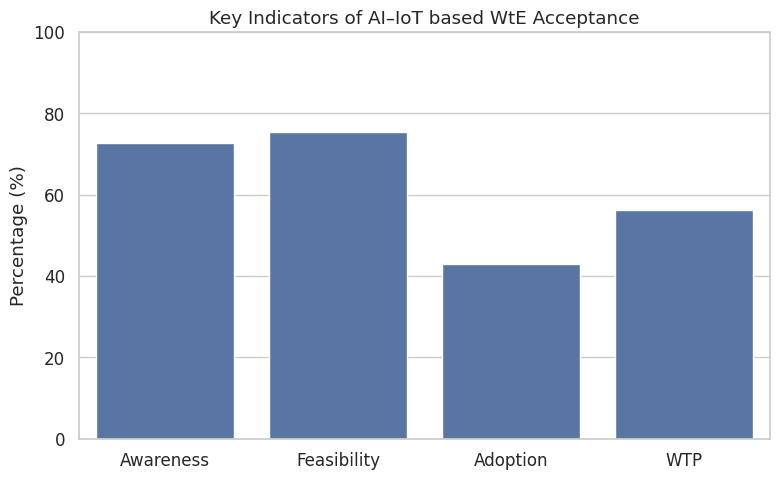

In [27]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=["Awareness", "Feasibility", "Adoption", "WTP"],
    y=desc["Value"].iloc[[0,1,2,4]]
)
plt.ylabel("Percentage (%)")
plt.title("Key Indicators of AI–IoT based WtE Acceptance")
plt.ylim(0,100)
plt.tight_layout()
plt.savefig("Fig1_Core_Indicators.png", dpi=300)
plt.show()


In [18]:
# 3 — BIVARIATE ASSOCIATIONS
chi_results = []

def chi_test(v1, v2):
    tab = pd.crosstab(df[v1], df[v2])
    chi2, p, _, _ = chi2_contingency(tab)
    chi_results.append([v1, v2, chi2, p])

# Socio-economic → Awareness
chi_test("Education", "WtE_Tech_Awarness")
chi_test("Expenditure", "WtE_Tech_Awarness")
chi_test("Distance_to_Waste_Point", "WtE_Tech_Awarness")

# Awareness → Outcomes
chi_test("WtE_Tech_Awarness", "Willingness_to_Adapt")
chi_test("WtE_Tech_Awarness", "Willingness_to_Pay")

chi_table = pd.DataFrame(
    chi_results,
    columns=["Variable 1", "Variable 2", "Chi-square", "p-value"]
)

chi_table.to_excel("Table2_ChiSquare.xlsx", index=False)
print(chi_table)


                Variable 1            Variable 2  Chi-square       p-value
0                Education     WtE_Tech_Awarness   64.669620  3.020428e-13
1              Expenditure     WtE_Tech_Awarness    8.413055  3.820362e-02
2  Distance_to_Waste_Point     WtE_Tech_Awarness    8.151718  1.697763e-02
3        WtE_Tech_Awarness  Willingness_to_Adapt   33.004306  6.810923e-08
4        WtE_Tech_Awarness    Willingness_to_Pay   19.822280  8.498627e-06


In [19]:
# 4 — LOGISTIC REGRESSION (CORE RESULT)

# Binary outcomes
df["Adopt_bin"] = (df["Willingness_to_Adapt"] == 1).astype(int)
df["Pay_bin"] = (df["Willingness_to_Pay"] == 1).astype(int)

X = df[
    ["WtE_Tech_Awarness", "Feasibility", "Personal_Interest",
     "Expenditure", "HH_Size", "Distance_to_Waste_Point"]
]
X = sm.add_constant(X)

# Adoption model
logit_adopt = sm.Logit(df["Adopt_bin"], X, missing='drop').fit(disp=0)

# WTP model
logit_pay = sm.Logit(df["Pay_bin"], X, missing='drop').fit(disp=0)

logit_adopt.summary2().tables[1].to_excel("Table3_Logit_Adopt.xlsx")
logit_pay.summary2().tables[1].to_excel("Table4_Logit_WTP.xlsx")


In [20]:
# 5 — MEDIATION (AWARENESS → FEASIBILITY → ADOPTION)
# Awareness → Feasibility
med1 = smf.ols("Feasibility ~ WtE_Tech_Awarness", data=df).fit()

# Awareness + Feasibility → Adoption
med2 = smf.logit(
    "Adopt_bin ~ WtE_Tech_Awarness + Feasibility",
    data=df
).fit(disp=0)

print(med1.summary().tables[1])
print(med2.summary2().tables[1])


                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept             0.8362      0.168      4.975      0.000       0.506       1.167
WtE_Tech_Awarness     0.9493      0.125      7.617      0.000       0.704       1.194
                      Coef.  Std.Err.         z     P>|z|    [0.025    0.975]
Intercept          1.884951  0.387254  4.867486  0.000001  1.125948  2.643955
WtE_Tech_Awarness -0.844055  0.290537 -2.905158  0.003671 -1.413496 -0.274613
Feasibility       -0.577742  0.120044 -4.812732  0.000001 -0.813025 -0.342459


In [21]:
#6 — MODEL DIAGNOSTICS
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(X.shape[1])]
print(vif)

MissingDataError: exog contains inf or nans

/tmp/ipython-input-2749057170.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="WtE_Tech_Awarness", y="Adopt_bin", data=df, ci=None)


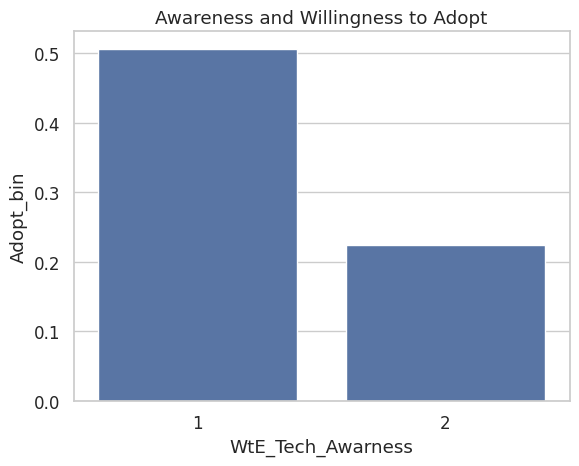

In [22]:
# 7 — VISUAL ANALYTICS (FIGS 2–6)
# Fig. 2 — Awareness → Adoption
sns.barplot(x="WtE_Tech_Awarness", y="Adopt_bin", data=df, ci=None)
plt.title("Awareness and Willingness to Adopt")
plt.savefig("Fig2_Awareness_Adopt.png", dpi=300)
plt.show()


/tmp/ipython-input-1819061351.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Feasibility", y="Adopt_bin", data=df, ci=None)


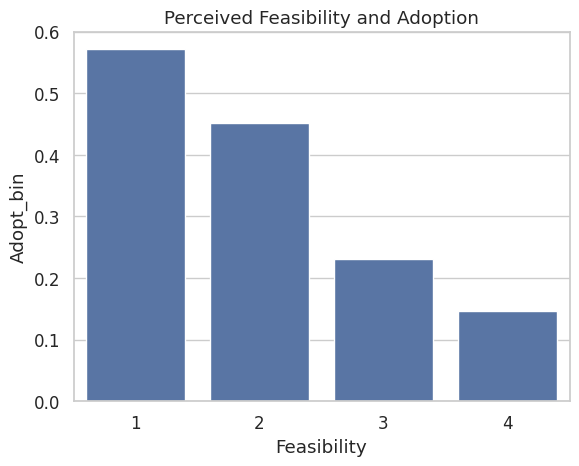

In [23]:
# Fig. 3 — Feasibility → Adoption
sns.barplot(x="Feasibility", y="Adopt_bin", data=df, ci=None)
plt.title("Perceived Feasibility and Adoption")
plt.savefig("Fig3_Feasibility_Adopt.png", dpi=300)
plt.show()


/tmp/ipython-input-1270210279.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="WtE_Tech_Awarness", y="Pay_bin", data=df, ci=None)


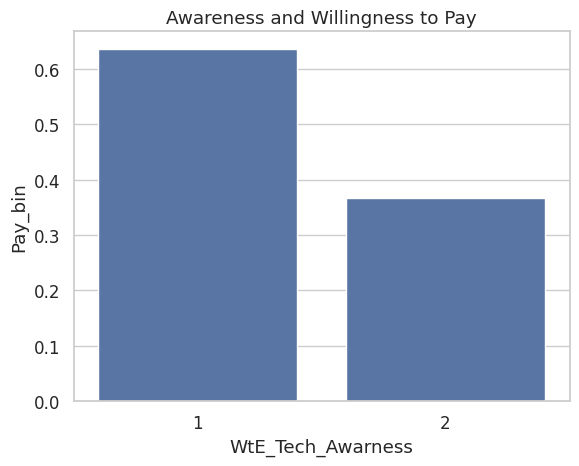

In [24]:
# Fig. 4 — Awareness → WTP
sns.barplot(x="WtE_Tech_Awarness", y="Pay_bin", data=df, ci=None)
plt.title("Awareness and Willingness to Pay")
plt.savefig("Fig4_Awareness_WTP.png", dpi=300)
plt.show()


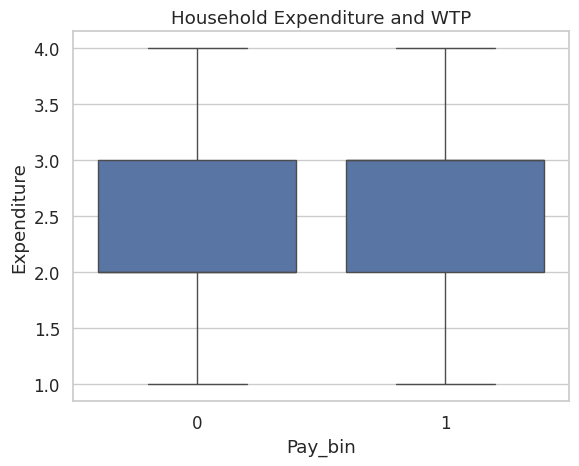

In [25]:
# Fig. 5 — Expenditure → WTP (Weak effect)
sns.boxplot(x="Pay_bin", y="Expenditure", data=df)
plt.title("Household Expenditure and WTP")
plt.savefig("Fig5_Expenditure_WTP.png", dpi=300)
plt.show()


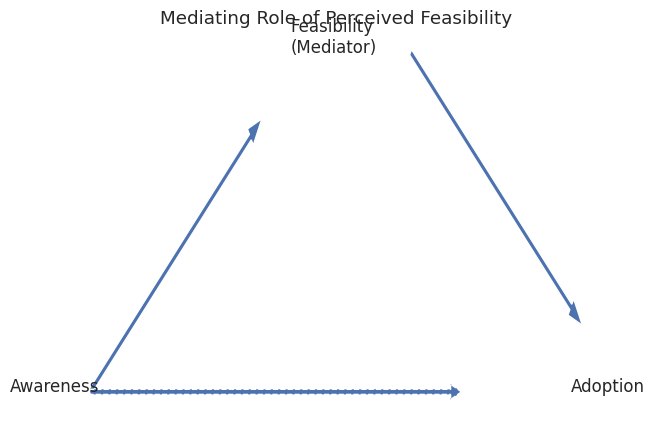

In [26]:
# Fig. 6 — Mediation Diagram
plt.figure(figsize=(7,5))
plt.text(0.1, 0.5, "Awareness", fontsize=12)
plt.text(0.45, 0.7, "Feasibility\n(Mediator)", fontsize=12)
plt.text(0.8, 0.5, "Adoption", fontsize=12)

plt.arrow(0.2,0.5,0.2,0.15, width=0.004)
plt.arrow(0.6,0.7,0.2,-0.15, width=0.004)
plt.arrow(0.2,0.5,0.45,0.0, linestyle="dashed", width=0.003)

plt.axis("off")
plt.title("Mediating Role of Perceived Feasibility")
plt.savefig("Fig6_Mediation_Path.png", dpi=300)
plt.show()
